In [8]:
import sys
import os
import torch
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# Añadir la carpeta src al path para importar nuestros módulos
sys.path.append(os.path.abspath('../src'))

from model import get_model

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Definir arquitectura (debe ser la misma que en train.py)
model = get_model(num_classes=3)

# 2. Cargar los pesos entrenados
# Si aún no has entrenado, este paso fallará hasta que exista el archivo .pth
MODEL_PATH = '../results/models/best_mias_model.pth'

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    print("✅ Modelo cargado exitosamente.")
else:
    print("❌ Error: No se encontró el archivo del modelo. Asegúrate de haber corrido train.py primero.")

✅ Modelo cargado exitosamente.


In [ ]:
def preprocess_image(img_path):
    # Leer imagen PGM
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"No se pudo leer la imagen en {img_path}")
    
    # Preprocesamiento Médico (CLAHE)
    img_8u = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(img_8u)
    
    # Preparar para el modelo (RGB + PIL + Transform)
    img_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    pil_img = Image.fromarray(img_rgb)
    
    # Transformaciones de inferencia
    inference_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    return inference_transforms(pil_img).unsqueeze(0).to(device), enhanced

def run_inference(img_id):
    search_pattern = os.path.join('../data/raw', f"{img_id}*.pgm")
    files = glob.glob(search_pattern)
    
    if not files:
        print(f"❌ Error: No se encontró ningún archivo para el ID: {img_id}")
        return
    
    # Tomamos el primer archivo encontrado
    img_path = files[0]
    print(f"Archivo encontrado: {img_path}")
    
    try:
        input_tensor, original_processed = preprocess_image(img_path)
        
        with torch.no_grad():
            output = model(input_tensor)
            probabilities = torch.nn.functional.softmax(output, dim=1)
            confidence, prediction = torch.max(probabilities, 1)
            
        classes = ['Normal', 'Benigno', 'Maligno']
        result_label = classes[prediction.item()]
        result_conf = confidence.item() * 100
        
        # Visualización
        plt.figure(figsize=(10, 5))
        plt.imshow(original_processed, cmap='gray')
        plt.title(f"ID: {img_id}\nPredicción: {result_label} ({result_conf:.2f}%)")
        plt.axis('off')
        plt.show()
        
        print(f"Probabilidades detalladas:")
        for i, class_name in enumerate(classes):
            print(f"- {class_name}: {probabilities[0][i].item()*100:.2f}%")
            
    except Exception as e:
        print(f"Error durante la inferencia: {e}")

Archivo encontrado: ../data/raw/mdb001lm.pgm


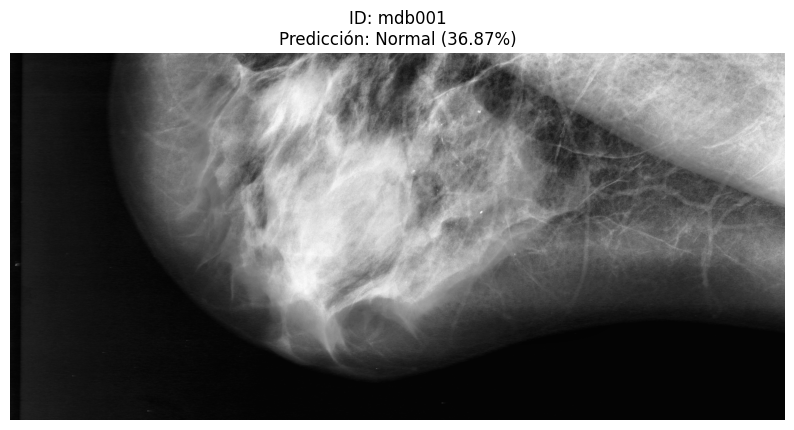

Probabilidades detalladas:
- Normal: 36.87%
- Benigno: 32.34%
- Maligno: 30.79%


In [ ]:
# Ejemplo con una imagen del dataset
run_inference("mdb001") 